In [1]:
import pandas as pd

# Load SOL CSV
sol_df = pd.read_csv(r'feature_datasets\SOL_features.csv', parse_dates=True, index_col=0)

# Define X and y
sol_y = sol_df['Close'].shift(-1)          # next-day close price
sol_X = sol_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
sol_X = sol_X.iloc[:-1]
sol_y = sol_y.iloc[:-1]

# Optional: check shapes
print("SOL X shape:", sol_X.shape)
print("SOL y shape:", sol_y.shape)

SOL X shape: (915, 29)
SOL y shape: (915,)


## Basis split 

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(sol_X) * 0.7)

sol_X_train = sol_X.iloc[:split_idx].values
sol_X_test  = sol_X.iloc[split_idx:].values

sol_y_train = sol_y.iloc[:split_idx].values
sol_y_test  = sol_y.iloc[split_idx:].values

print("ETH X_train shape:", sol_X_train.shape)
print("ETH X_test shape:", sol_X_test.shape)
print("ETH y_train shape:", sol_y_train.shape)
print("ETH y_test shape:", sol_y_test.shape)

ETH X_train shape: (640, 29)
ETH X_test shape: (275, 29)
ETH y_train shape: (640,)
ETH y_test shape: (275,)


In [3]:
sol_test_dates = sol_df.index[-len(sol_X_test):]

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
sol_X_train_scaled = scaler.fit_transform(sol_X_train)

# Transform TEST using the same scaler
sol_X_test_scaled = scaler.transform(sol_X_test)

# Check shapes
print("Scaled X_train shape:", sol_X_train_scaled.shape)
print("Scaled X_test shape:", sol_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [5]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
sol_y_train_scaled = y_scaler.fit_transform(sol_y_train.reshape(-1,1)).flatten()

# Scale test target
sol_y_test_scaled = y_scaler.transform(sol_y_test.reshape(-1,1)).flatten()


In [6]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for SOL using scaled target
sol_X_train_seq, sol_y_train_seq = create_sequences(sol_X_train_scaled, sol_y_train_scaled, time_steps=30)
sol_X_test_seq, sol_y_test_seq = create_sequences(sol_X_test_scaled, sol_y_test_scaled, time_steps=30)

# Check shapes
print("SOL X_train_seq shape:", sol_X_train_seq.shape)
print("SOL y_train_seq shape:", sol_y_train_seq.shape)
print("SOL X_test_seq shape:", sol_X_test_seq.shape)
print("SOL y_test_seq shape:", sol_y_test_seq.shape)

SOL X_train_seq shape: (610, 30, 29)
SOL y_train_seq shape: (610,)
SOL X_test_seq shape: (245, 30, 29)
SOL y_test_seq shape: (245,)


### Model training

In [7]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [8]:
# Get number of features from the sequences
input_size = sol_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)


In [9]:
model = train_model(model, sol_X_train_seq, sol_y_train_seq, epochs=50, batch_size=32, lr=0.001
)


Epoch [10/50], Loss: 0.004210
Epoch [20/50], Loss: 0.001483
Epoch [30/50], Loss: 0.006524
Epoch [40/50], Loss: 0.010446
Epoch [50/50], Loss: 0.008400


In [10]:
sol_preds = predict_model(model, sol_X_test_seq)

# check
print("Predictions shape:", sol_preds.shape)
print("First 10 predictions:", sol_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.08848631]
 [0.08277691]
 [0.07789928]
 [0.07269051]
 [0.07193335]
 [0.06853785]
 [0.07025073]
 [0.06760067]
 [0.05624862]
 [0.06051661]]


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
sol_preds_actual = y_scaler.inverse_transform(sol_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
sol_y_test_actual = sol_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(sol_y_test_actual, sol_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_y_test_actual, sol_preds_actual)
r2 = r2_score(sol_y_test_actual, sol_preds_actual)
mape = np.mean(np.abs((sol_y_test_actual - sol_preds_actual) / sol_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 27.59
RMSE: 5.25
MAE: 3.77
R2 Score: 0.9488
MAPE: 12.50%


In [12]:
sol_preds_actual = y_scaler.inverse_transform(sol_preds.reshape(-1,1))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = sol_df.index[-len(sol_X_test):][30:]  # test dates aligned with sequences
actual_seq = sol_y_test[30:]                      # actual prices aligned
pred_seq = sol_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot.head()

,Actual,Predicted
Date,,
2023-05-02,22.264978,31.709875
2023-05-03,22.218002,30.286621
2023-05-04,21.730349,29.070715
2023-05-05,22.826111,27.772259
2023-05-06,21.974262,27.583511


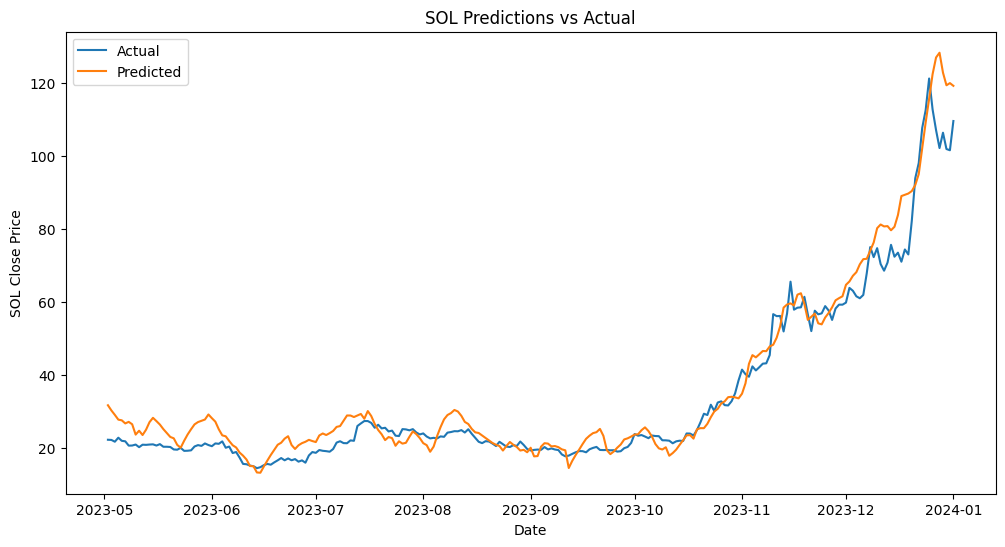

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% split

In [15]:
# Get unique years from your DataFrame index
years = sol_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [16]:
X_train_list = []
y_train_list = []

In [17]:
for year in years:
    # Filter data for this year
    sol_year = sol_df[sol_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(sol_year) * 0.7)

    # Take first 70% as training
    X_train_year = sol_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = sol_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [18]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)


Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [19]:
X_test_list = []
y_test_list = []

In [20]:
for year in years:
    sol_year = sol_df[sol_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(sol_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = sol_year.iloc[split_idx:, 1:].values   # features
    y_test_year = sol_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [21]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [23]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [24]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Model training 

In [25]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [26]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [27]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.004293
Epoch [20/50], Loss: 0.001894
Epoch [30/50], Loss: 0.005153
Epoch [40/50], Loss: 0.003196
Epoch [50/50], Loss: 0.001017


In [28]:
sol_preds_ev_year = predict_model(model_y, X_test_seq)
sol_preds_ev_year[:10]

array([[0.7468134 ],
       [0.73365   ],
       [0.72359   ],
       [0.7180351 ],
       [0.7125313 ],
       [0.68192023],
       [0.6622439 ],
       [0.6599792 ],
       [0.662513  ],
       [0.6465836 ]], dtype=float32)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
sol_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
sol_preds_actual = y_scaler.inverse_transform(sol_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
sol_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(sol_y_test_actual, sol_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_y_test_actual, sol_preds_actual)
r2 = r2_score(sol_y_test_actual, sol_preds_actual)
mape = np.mean(np.abs((sol_y_test_actual - sol_preds_actual) / sol_y_test_actual)) * 100 

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 107.74
RMSE: 10.38
MAE: 4.88
R2 Score: 0.9566
MAPE: 14.26%


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = sol_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_sol_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_sol_plot_year.head()


,Actual,Predicted
0,194.199219,187.279861
1,190.596909,184.154800
2,194.621704,181.766495
3,181.178085,180.447723
4,167.954834,179.141098


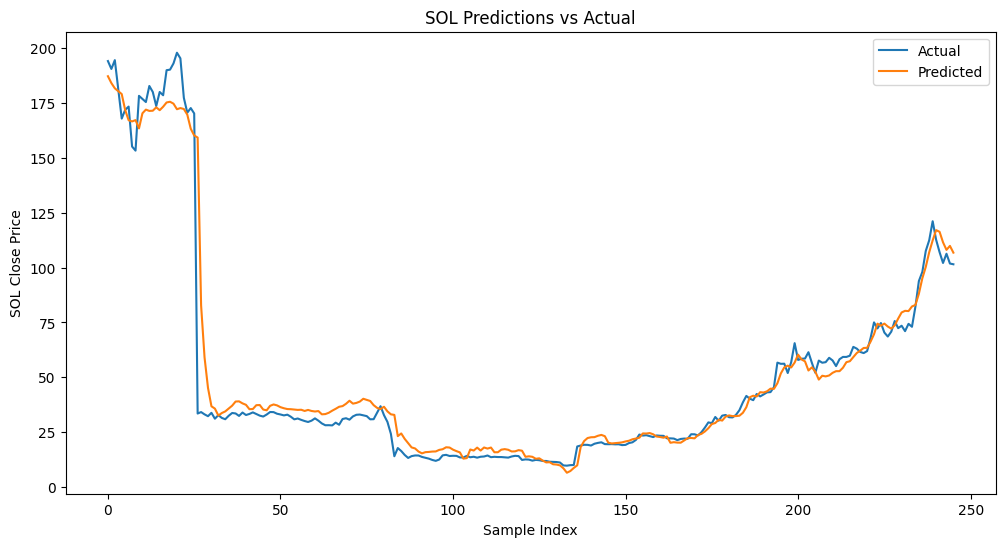

In [31]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_sol_plot_year["Actual"], label="Actual")
plt.plot(df_sol_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual")
plt.legend()
plt.show()


## Three quaters split model training

In [32]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(sol_X) * 0.75)

sol_q3_X_train = sol_X.iloc[:q3_split_idx].values
sol_q3_X_test  = sol_X.iloc[q3_split_idx:].values

sol_q3_y_train = sol_y.iloc[:q3_split_idx].values
sol_q3_y_test  = sol_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 SOL X_train shape:", sol_q3_X_train.shape)
print("Q3 SOL X_test shape:", sol_q3_X_test.shape)
print("Q3 SOL y_train shape:", sol_q3_y_train.shape)
print("Q3 SOL y_test shape:", sol_q3_y_test.shape)


Q3 SOL X_train shape: (686, 29)
Q3 SOL X_test shape: (229, 29)
Q3 SOL y_train shape: (686,)
Q3 SOL y_test shape: (229,)


In [33]:
# Assuming sol_df has Date as index
sol_q3_test_dates = sol_df.index[-len(sol_q3_X_test):]

print("Q3 test dates length:", len(sol_q3_test_dates))

Q3 test dates length: 229


In [34]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
sol_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
sol_q3_X_train_scaled = sol_q3_X_scaler.fit_transform(sol_q3_X_train)

# Transform TEST using same scaler
sol_q3_X_test_scaled = sol_q3_X_scaler.transform(sol_q3_X_test)

print("Q3 Scaled X_train shape:", sol_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", sol_q3_X_test_scaled.shape)

Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [35]:
# Target scaler
sol_q3_y_scaler = MinMaxScaler()

# Scale training target
sol_q3_y_train_scaled = sol_q3_y_scaler.fit_transform(
    sol_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
sol_q3_y_test_scaled = sol_q3_y_scaler.transform(
    sol_q3_y_test.reshape(-1, 1)
).flatten()


print("Q3 Scaled y_train shape:", sol_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", sol_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [36]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [37]:
# Create sequences (30-day window)
sol_q3_X_train_seq, sol_q3_y_train_seq = create_sequences_q3(
    sol_q3_X_train_scaled,
    sol_q3_y_train_scaled,
    time_steps=30
)

sol_q3_X_test_seq, sol_q3_y_test_seq = create_sequences_q3(
    sol_q3_X_test_scaled,
    sol_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", sol_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", sol_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", sol_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", sol_q3_y_test_seq.shape)

Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Training the model

In [38]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [39]:
# Get number of features
sol_q3_input_size = sol_q3_X_train_seq.shape[2]

# Initialize model
sol_q3_model = BiLSTM(input_size=sol_q3_input_size)

In [42]:
# Train model
sol_q3_model = train_model(sol_q3_model, sol_q3_X_train_seq, sol_q3_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.003817
Epoch [20/50], Loss: 0.006265
Epoch [30/50], Loss: 0.007539
Epoch [40/50], Loss: 0.003592
Epoch [50/50], Loss: 0.003775


In [43]:
# Generate predictions
sol_q3_preds = predict_model(sol_q3_model, sol_q3_X_test_seq)

print("Q3 Predictions shape:", sol_q3_preds.shape)
print("First 10 Q3 predictions:", sol_q3_preds[:10])


Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.02450253]
 [0.02912775]
 [0.03334573]
 [0.03705228]
 [0.03792477]
 [0.032515  ]
 [0.03288343]
 [0.03289791]
 [0.03145013]
 [0.03641866]]


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
sol_q3_preds_eval = predict_model(sol_q3_model, sol_q3_X_test_seq)

# Inverse scale predictions to original price values
sol_q3_preds_actual = sol_q3_y_scaler.inverse_transform(
    sol_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
sol_q3_y_test_actual = sol_q3_y_scaler.inverse_transform(
    sol_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
sol_q3_mse = mean_squared_error(sol_q3_y_test_actual, sol_q3_preds_actual)
sol_q3_rmse = np.sqrt(sol_q3_mse)
sol_q3_mae = mean_absolute_error(sol_q3_y_test_actual, sol_q3_preds_actual)
sol_q3_r2 = r2_score(sol_q3_y_test_actual, sol_q3_preds_actual)
sol_q3_mape = np.mean(np.abs((sol_q3_y_test_actual - sol_q3_preds_actual) / sol_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {sol_q3_mse:.2f}")
print(f"Q3 RMSE: {sol_q3_rmse:.2f}")
print(f"Q3 MAE: {sol_q3_mae:.2f}")
print(f"Q3 R2 Score: {sol_q3_r2:.4f}")
print(f"Q3 MAPE: {sol_q3_mape:.2f}%")

Q3 MSE: 20.94
Q3 RMSE: 4.58
Q3 MAE: 3.42
Q3 R2 Score: 0.9656
Q3 MAPE: 10.33%


In [45]:
# Inverse scale predictions
sol_q3_preds_actual = sol_q3_y_scaler.inverse_transform(
    sol_q3_preds.reshape(-1, 1)
)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
sol_q3_dates_seq = sol_df.index[-len(sol_q3_X_test):][30:]
sol_q3_actual_seq = sol_q3_y_test[30:]
sol_q3_pred_seq = sol_q3_preds_actual.flatten()

# Create DataFrame
sol_q3_df_plot = pd.DataFrame({
    "Date": sol_q3_dates_seq,
    "Actual": sol_q3_actual_seq,
    "Predicted": sol_q3_pred_seq
})

sol_q3_df_plot.set_index("Date", inplace=True)
sol_q3_df_plot

,Actual,Predicted
Date,,
2023-06-17,15.650521,15.759836
2023-06-18,15.438235,16.912821
2023-06-19,16.073042,17.964291
2023-06-20,16.635231,18.888269
2023-06-21,17.257046,19.105766
...,...,...
2023-12-28,102.104568,120.485710
2023-12-29,106.311516,113.435638
2023-12-30,101.845085,111.683762


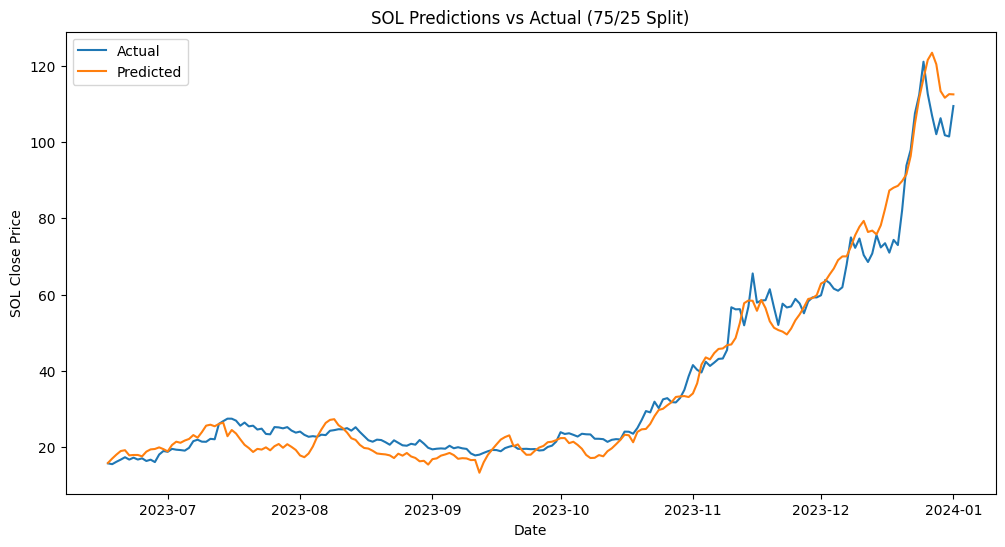

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(sol_q3_df_plot["Actual"], label="Actual")
plt.plot(sol_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

# Finetuning the models using optuna

In [48]:
import optuna

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
from sklearn.model_selection import train_test_split

sol_q3_X_train_tune, sol_q3_X_val_tune, sol_q3_y_train_tune, sol_q3_y_val_tune = train_test_split(
    sol_q3_X_train_seq,
    sol_q3_y_train_seq,
    test_size=0.2,
    shuffle=False
)

In [50]:
import torch
import numpy as np

def objective(trial):

    # Hyperparameters to tune
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Get input size
    input_size = sol_q3_X_train_tune.shape[2]

    # Create model
    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    # Train model
    model = train_model(
        model,
        sol_q3_X_train_tune,
        sol_q3_y_train_tune,
        epochs=30,
        batch_size=batch_size,
        lr=lr
    )

    # Validation prediction
    preds = predict_model(model, sol_q3_X_val_tune)

    # Calculate validation MSE
    val_loss = np.mean((preds.flatten() - sol_q3_y_val_tune) ** 2)

    return val_loss

In [51]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-16 21:03:03,441] A new study created in memory with name: no-name-ef68b462-eca9-4543-9cfe-439f10f24662
C:\Users\tharu\AppData\Local\Temp\ipykernel_1884\1950460389.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Epoch [10/30], Loss: 0.004858
Epoch [20/30], Loss: 0.007113


[I 2026-03-16 21:03:28,629] Trial 0 finished with value: 0.0012522146351727267 and parameters: {'hidden_size': 116, 'num_layers': 1, 'lr': 0.007104241243943758, 'batch_size': 16}. Best is trial 0 with value: 0.0012522146351727267.


Epoch [30/30], Loss: 0.002673
Epoch [10/30], Loss: 0.004572
Epoch [20/30], Loss: 0.003402


[I 2026-03-16 21:04:54,747] Trial 1 finished with value: 0.00012155792702720703 and parameters: {'hidden_size': 115, 'num_layers': 3, 'lr': 0.00032624323917055547, 'batch_size': 16}. Best is trial 1 with value: 0.00012155792702720703.


...

Epoch [30/30], Loss: 0.003380
Epoch [10/30], Loss: 0.021448
Epoch [20/30], Loss: 0.003446


[I 2026-03-16 21:08:16,268] Trial 8 finished with value: 0.00046657521100788174 and parameters: {'hidden_size': 63, 'num_layers': 2, 'lr': 0.009802510764991054, 'batch_size': 16}. Best is trial 2 with value: 8.064751547932532e-05.


Epoch [30/30], Loss: 0.003118
Epoch [10/30], Loss: 0.003511
Epoch [20/30], Loss: 0.004317


[I 2026-03-16 21:08:26,859] Trial 9 finished with value: 0.00014241898059794172 and parameters: {'hidden_size': 98, 'num_layers': 1, 'lr': 0.0006412222179495053, 'batch_size': 64}. Best is trial 2 with value: 8.064751547932532e-05.


Epoch [30/30], Loss: 0.001536


In [52]:
print(study.best_params)

{'hidden_size': 74, 'num_layers': 2, 'lr': 0.0020601601839391154, 'batch_size': 16}


In [53]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [54]:
vis.plot_param_importances(study)

In [55]:
vis.plot_parallel_coordinate(study)

### Testing new parameters

In [56]:
# Best parameters from Optuna
best_params = study.best_params

# Get input size
input_size = sol_q3_X_train_seq.shape[2]

# Create final tuned model
model_tuned = BiLSTM(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"]
)

# Train final model on full training data
model_tuned = train_model(
    model_tuned,
    sol_q3_X_train_seq,
    sol_q3_y_train_seq,
    epochs=50,
    batch_size=best_params["batch_size"],
    lr=best_params["lr"]
)

Epoch [10/50], Loss: 0.003310
Epoch [20/50], Loss: 0.001942
Epoch [30/50], Loss: 0.005590
Epoch [40/50], Loss: 0.001093
Epoch [50/50], Loss: 0.004856


In [57]:
sol_preds_tuned = predict_model(model_tuned, sol_q3_X_test_seq)
sol_preds_tuned[:10]

array([[0.03802894],
       [0.0406044 ],
       [0.04386824],
       [0.04617492],
       [0.04606375],
       [0.04570703],
       [0.04530932],
       [0.04105591],
       [0.03965084],
       [0.04245067]], dtype=float32)

In [58]:
sol_preds_tuned_actual = sol_q3_y_scaler.inverse_transform(sol_preds_tuned.reshape(-1,1))

In [59]:
sol_y_test_actual = y_scaler.inverse_transform(sol_y_test_seq.reshape(-1,1))

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(sol_q3_y_test_actual, sol_preds_tuned_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_q3_y_test_actual, sol_preds_tuned_actual)
r2 = r2_score(sol_q3_y_test_actual, sol_preds_tuned_actual)
mape = np.mean(np.abs((sol_q3_y_test_actual - sol_preds_tuned_actual) / sol_q3_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 26.55
RMSE: 5.15
MAE: 3.53
R2 Score: 0.9563
MAPE: 10.12%


# Saving the best performed model

In [61]:
torch.save(sol_q3_model.state_dict(), "SOL_final_model.pth")